# Advanced SQL E-Commerce Business Analysis Using Olist Dataset

## 1. Project Overview & Business Objective

### Project Overview

This project presents an end-to-end e-commerce business analysis using the Olist Brazilian E-Commerce dataset. The dataset contains real marketplace information related to customer orders, products, sellers, payments, delivery timelines, customer locations, and review scores.

The main purpose of this project is to analyze marketplace performance from a business analyst perspective using SQL. Instead of only running basic queries, this project focuses on converting raw transactional data into meaningful business insights related to revenue growth, customer behavior, product performance, seller performance, delivery efficiency, payment behavior, and customer satisfaction.

The analysis is performed in a Kaggle Notebook using Python, Pandas, SQLite, and SQL. The CSV files are first loaded, transformed, and converted into SQL tables. After database creation, advanced SQL queries are used to perform KPI analysis, trend analysis, ranking, segmentation, and operational performance analysis.

---

### Business Objective

The business objective of this project is to help an e-commerce marketplace understand:

- How the business is performing in terms of revenue, orders, and customer growth
- Which product categories and sellers are contributing the most to revenue
- Which customer locations are generating the highest business value
- Whether customers are making repeat purchases or mostly one-time purchases
- How delivery delays affect customer satisfaction and review scores
- Which customers can be classified as high-value, loyal, normal, or at-risk
- What business actions can improve revenue, retention, delivery performance, and customer experience

---

### ETL Approach Used in This Project

This project follows a simple ETL workflow:

#### Extract

Raw CSV files are extracted from the Olist e-commerce dataset, including:

- Orders data
- Order items data
- Customers data
- Products data
- Sellers data
- Payments data
- Reviews data
- Product category translation data

#### Transform

The data is prepared for analysis by:

- Loading CSV files into Pandas DataFrames
- Checking table structure and row counts
- Identifying missing values
- Standardizing table names
- Understanding relationships between tables
- Preparing date columns for time-based analysis
- Creating derived business metrics such as revenue, delivery delay, average order value, and customer frequency

#### Load

The transformed DataFrames are loaded into a SQLite database.  
This allows SQL queries to be executed directly inside the Kaggle Notebook for structured business analysis.

---

### Advanced SQL Techniques Used

This project applies advanced SQL methods commonly used in business and data analyst roles, including:

- Multi-table joins
- Common Table Expressions, also known as CTEs
- Window functions
- Ranking functions such as RANK and DENSE_RANK
- LAG function for month-over-month growth analysis
- NTILE function for customer segmentation
- CASE WHEN statements for business classification
- Conditional aggregation
- Date-based analysis
- Customer-level aggregation
- Revenue contribution analysis
- RFM customer segmentation
- Delivery performance analysis
- Review score impact analysis

---

### Key Business Questions

This project answers the following business questions:

1. What are the total orders, total revenue, total customers, and average order value?
2. How does monthly revenue change over time?
3. What is the month-over-month revenue growth rate?
4. Which product categories generate the highest revenue?
5. Which categories contribute the highest percentage of total sales?
6. Which sellers are the top performers based on revenue and order volume?
7. Which customer states and cities generate the most orders and revenue?
8. What percentage of customers are repeat customers?
9. Which customers are high-value, loyal, normal, or at-risk based on RFM segmentation?
10. What percentage of orders are delivered late?
11. Which locations face the highest delivery delays?
12. Does late delivery reduce customer review scores?
13. Which payment methods are most preferred by customers?
14. What business recommendations can improve sales, customer retention, and customer satisfaction?

---

### Business Analyst Perspective

As a business analyst, the goal of this project is not only to write SQL queries but also to generate actionable insights for business decision-making.

This project focuses on identifying:

- Revenue growth trends
- High-performing product categories
- Top and low-performing sellers
- Valuable customer locations
- Repeat purchase behavior
- Customer segments based on value
- Delivery delay patterns
- Relationship between delivery performance and review scores
- Payment preferences
- Practical business recommendations

---

### Expected Business Outcomes

At the end of this project, the analysis will help the business understand:

- Which areas are driving revenue growth
- Which product categories should be promoted
- Which sellers need monitoring or support
- Which customer segments should be targeted with marketing campaigns
- Which regions need delivery improvement
- How customer satisfaction can be improved through better logistics
- How SQL can be used to solve real business problems

---

### Tools Used

- Kaggle Notebook
- Python
- Pandas
- SQLite
- SQL
- Matplotlib
- CSV-based ETL workflow

---

### Final Project Goal

The final goal of this project is to create a recruiter-friendly SQL portfolio project that demonstrates strong business understanding, ETL workflow, advanced SQL querying, KPI analysis, customer segmentation, and data-driven recommendation skills.

## 2. Data Preparation & Database Setup

This section follows an ETL approach to prepare the Olist e-commerce dataset for SQL-based business analysis.

The ETL process includes:

- **Extract:** Load raw CSV files from the Kaggle dataset.
- **Transform:** Standardize table names, check structure, understand relationships, and prepare data for analysis.
- **Load:** Convert all required CSV files into SQLite database tables so that advanced SQL queries can be executed inside the notebook.

This step is important because business analysis should be performed on a properly structured database rather than directly analyzing scattered CSV files.

In [52]:
# Importing libraries
import pandas as pd
import sqlite3
import os

In [53]:
# Check dataset file path
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce


### Extract: Loading Raw CSV Files

The dataset contains multiple CSV files related to orders, customers, sellers, products, payments, reviews, and product categories.

For this project, the most important business tables are loaded into Pandas DataFrames.

In [54]:
base_path = "//kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce"

orders = pd.read_csv(f"{base_path}/olist_orders_dataset.csv")
order_items = pd.read_csv(f"{base_path}/olist_order_items_dataset.csv")
customers = pd.read_csv(f"{base_path}/olist_customers_dataset.csv")
products = pd.read_csv(f"{base_path}/olist_products_dataset.csv")
sellers = pd.read_csv(f"{base_path}/olist_sellers_dataset.csv")
payments = pd.read_csv(f"{base_path}/olist_order_payments_dataset.csv")
reviews = pd.read_csv(f"{base_path}/olist_order_reviews_dataset.csv")
category_translation = pd.read_csv(f"{base_path}/product_category_name_translation.csv")

### Transform: Understanding the Loaded Data

Before loading the data into SQL tables, we first check the shape of each dataset.  
This helps us understand the size of the data and confirm that all files were loaded correctly.

In [55]:
datasets = {
    "orders": orders,
    "order_items": order_items,
    "customers": customers,
    "products": products,
    "sellers": sellers,
    "payments": payments,
    "reviews": reviews,
    "category_translation": category_translation
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} rows and {df.shape[1]} columns")

orders: 99441 rows and 8 columns
order_items: 112650 rows and 7 columns
customers: 99441 rows and 5 columns
products: 32951 rows and 9 columns
sellers: 3095 rows and 4 columns
payments: 103886 rows and 5 columns
reviews: 99224 rows and 7 columns
category_translation: 71 rows and 2 columns


In [56]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [57]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [58]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


### Load: Creating SQLite Database

After loading the CSV files, a SQLite database is created.  
Each DataFrame is converted into a SQL table so that business analysis can be performed using SQL queries.

In [59]:
conn = sqlite3.connect("olist_ecommerce.db")

In [60]:
orders.to_sql("orders", conn, if_exists="replace", index=False)
order_items.to_sql("order_items", conn, if_exists="replace", index=False)
customers.to_sql("customers", conn, if_exists="replace", index=False)
products.to_sql("products", conn, if_exists="replace", index=False)
sellers.to_sql("sellers", conn, if_exists="replace", index=False)
payments.to_sql("payments", conn, if_exists="replace", index=False)
reviews.to_sql("reviews", conn, if_exists="replace", index=False)
category_translation.to_sql("category_translation", conn, if_exists="replace", index=False)

71

### Checking Created SQL Tables

After loading the data into SQLite, we verify whether all required tables have been successfully created.

In [61]:
query = """
SELECT name AS table_name
FROM sqlite_master
WHERE type = 'table';
"""

pd.read_sql_query(query, conn)

,table_name
0,orders
1,order_items
2,customers
3,products
4,sellers
5,payments
6,reviews
7,category_translation


### Creating Helper Function for SQL Queries

A helper function is created to run SQL queries easily and return the output as a Pandas DataFrame.

This makes the notebook cleaner and helps execute multiple business analysis queries efficiently.

In [62]:
def run_query(query):
    return pd.read_sql_query(query, conn)

In [63]:
# Test SQL Function
run_query("""
SELECT *
FROM orders
LIMIT 5;
""")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


### Database Relationship Understanding

The Olist dataset follows a relational database structure.  
Understanding table relationships is important before performing advanced SQL analysis.

Key relationships used in this project:

- `orders.order_id` connects with `order_items.order_id`
- `orders.order_id` connects with `payments.order_id`
- `orders.order_id` connects with `reviews.order_id`
- `orders.customer_id` connects with `customers.customer_id`
- `order_items.product_id` connects with `products.product_id`
- `order_items.seller_id` connects with `sellers.seller_id`
- `products.product_category_name` connects with `category_translation.product_category_name`

These relationships will be used for revenue analysis, product performance analysis, seller ranking, customer segmentation, delivery analysis, and review score analysis.

In [64]:
# Row Count Validation
run_query("""
SELECT 'orders' AS table_name, COUNT(*) AS total_rows FROM orders
UNION ALL
SELECT 'order_items', COUNT(*) FROM order_items
UNION ALL
SELECT 'customers', COUNT(*) FROM customers
UNION ALL
SELECT 'products', COUNT(*) FROM products
UNION ALL
SELECT 'sellers', COUNT(*) FROM sellers
UNION ALL
SELECT 'payments', COUNT(*) FROM payments
UNION ALL
SELECT 'reviews', COUNT(*) FROM reviews
UNION ALL
SELECT 'category_translation', COUNT(*) FROM category_translation;
""")

,table_name,total_rows
0,orders,99441
1,order_items,112650
2,customers,99441
3,products,32951
4,sellers,3095
5,payments,103886
6,reviews,99224
7,category_translation,71


### Section Summary

In this section, the raw Olist CSV files were extracted, loaded into Pandas, transformed into structured table format, and stored inside a SQLite database.

The database is now ready for advanced SQL analysis.

In the next section, we will perform data quality checks and calculate business KPIs such as total orders, total revenue, total customers, average order value, delivered order percentage, and total sellers.

## 3. Data Quality & Business KPI Overview

Before performing advanced business analysis, it is important to validate the dataset and understand the overall business performance.

This section focuses on two parts:

1. **Data Quality Check**  
   To check row counts, order status distribution, missing values, duplicate records, and date consistency.

2. **Business KPI Overview**  
   To calculate key business metrics such as total revenue, total orders, delivered orders, unique customers, sellers, average order value, freight cost, and average review score.

This step helps ensure that the dataset is reliable and ready for advanced SQL analysis.

In [65]:
run_query("""
SELECT 'orders' AS table_name, COUNT(*) AS total_rows FROM orders
UNION ALL
SELECT 'order_items', COUNT(*) FROM order_items
UNION ALL
SELECT 'customers', COUNT(*) FROM customers
UNION ALL
SELECT 'products', COUNT(*) FROM products
UNION ALL
SELECT 'sellers', COUNT(*) FROM sellers
UNION ALL
SELECT 'payments', COUNT(*) FROM payments
UNION ALL
SELECT 'reviews', COUNT(*) FROM reviews
UNION ALL
SELECT 'category_translation', COUNT(*) FROM category_translation;
""")

,table_name,total_rows
0,orders,99441
1,order_items,112650
2,customers,99441
3,products,32951
4,sellers,3095
5,payments,103886
6,reviews,99224
7,category_translation,71


### Business Interpretation

*   *Operational Scale:* With nearly *100,000 orders* and customers, this dataset represents a statistically robust and mature ecommerce ecosystem.
*   *Customer Engagement:* The high volume of *99,000 reviews* indicates an exceptionally active feedback loop, providing rich text/sentiment data for customer satisfaction analysis.
*   *Marketplace Depth:* A broad catalog of *33,000 products* supplied by *3,000 sellers* demonstrates strong market diversity and platform scale.
*   *Data Integrity:* This baseline row count validates that all core relational entities (orders, items, customers, payments, and reviews) loaded completely and are ready for advanced SQL analysis.

In [66]:
order_status_distribution = run_query("""
SELECT 
    order_status,
    COUNT(*) AS total_orders,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders), 2) AS percentage_share
FROM orders
GROUP BY order_status
ORDER BY total_orders DESC;
""")

order_status_distribution

,order_status,total_orders,percentage_share
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


### Business Interpretation

*   *High Fulfillment Success:* An overwhelming *97.02% of orders are successfully delivered*, indicating a highly reliable and efficient logistics and fulfillment pipeline.
*   *Low Attrition Rate:* Combined *canceled and unavailable orders account for only ~1.24%* of total volume, reflecting strong inventory management and low customer friction.
*   *Active Pipeline:* Approximately *1.7% of orders are currently in-flight* (shipped, processing, invoiced, created, or approved), representing steady ongoing operational activity.
*   *Actionable Insight:* The baseline looks exceptionally healthy; future deep-dives could investigate the specific root causes behind the 625 canceled and 609 unavailable orders to minimize lost revenue.

In [67]:
run_query("""
SELECT 
    COUNT(*) AS total_orders,
    SUM(CASE WHEN order_purchase_timestamp IS NULL THEN 1 ELSE 0 END) AS missing_purchase_date,
    SUM(CASE WHEN order_approved_at IS NULL THEN 1 ELSE 0 END) AS missing_approval_date,
    SUM(CASE WHEN order_delivered_carrier_date IS NULL THEN 1 ELSE 0 END) AS missing_carrier_delivery_date,
    SUM(CASE WHEN order_delivered_customer_date IS NULL THEN 1 ELSE 0 END) AS missing_customer_delivery_date,
    SUM(CASE WHEN order_estimated_delivery_date IS NULL THEN 1 ELSE 0 END) AS missing_estimated_delivery_date
FROM orders;
""")

,total_orders,missing_purchase_date,missing_approval_date,missing_carrier_delivery_date,missing_customer_delivery_date,missing_estimated_delivery_date
0,99441,0,160,1783,2965,0


### Business Interpretation

*   *Perfect Transaction Integrity:* Zero missing purchase dates confirm that *100% of orders are cleanly captured* at inception, establishing a reliable baseline for order volume tracking.
*   *Minor Approval Gaps:* A negligible *0.16% (160 orders) lack an approval timestamp*, which likely points to edge cases like immediate system cancellations or direct-to-ship orders.
*   *Logistics Pipeline Drop-offs:* Missing carrier (1,783) and customer delivery dates (2,965) represent only *~1.8% and ~3.0% of the total dataset* respectively.
*   *Operational Alignment:* These missing delivery timestamps naturally align with the previous cell's metrics showing a small percentage of unfulfilled, canceled, or in-flight orders rather than actual missing data quality issues

In [68]:
run_query("""
SELECT 
    order_id,
    COUNT(*) AS duplicate_count
FROM orders
GROUP BY order_id
HAVING COUNT(*) > 1;
""")

,order_id,duplicate_count


### Business Interpretation

*   *Zero Duplicate Orders:* Validates primary key uniqueness.
*   *Data Integrity Confirmed:* Each row represents one distinct transaction.
*   *Safe Downstream Joins:* Prevents artificial row inflation during analytics.

In [69]:
run_query("""
SELECT 
    COUNT(*) AS total_products,
    SUM(CASE WHEN product_category_name IS NULL THEN 1 ELSE 0 END) AS missing_product_category,
    ROUND(
        SUM(CASE WHEN product_category_name IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
        2
    ) AS missing_category_percentage
FROM products;
""")

,total_products,missing_product_category,missing_category_percentage
0,32951,610,1.85


### Business Interpretation

*   *High Categorization Coverage:* Over *98% of products* are properly mapped to a category, ensuring reliable product group reporting.
*   *Minor Data Gaps:* Only *1.85% (610 items)* lack a category designation.
*   *Actionable Clean-up:* These unclassified items should be bucketed into an "Other/Uncategorized" tag to avoid exclusion from inventory or recommendation pipelines.

In [70]:
run_query("""
SELECT 
    COUNT(*) AS total_delivered_orders,
    SUM(
        CASE 
            WHEN order_delivered_customer_date < order_purchase_timestamp 
            THEN 1 ELSE 0 
        END
    ) AS invalid_delivery_dates
FROM orders
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL;
""")

,total_delivered_orders,invalid_delivery_dates
0,96470,0


### Business Interpretation

*   *Flawless Delivery Timeline Integrity:* Zero invalid delivery dates across all 96,470 delivered orders confirms the logistics timestamps are logically sound.
*   *Reliable Performance Metrics:* This clean data allows for highly accurate calculations of shipping durations, fulfillment speeds, and SLA compliance.
*   *Production-Ready Baseline:* The fulfillment dataset is completely validated and safe for advanced delivery performance analytics.

### Business KPI Overview

After checking data quality, we calculate high-level business KPIs to understand overall marketplace performance.

The KPIs include:

- Total orders
- Delivered orders
- Delivery success rate
- Total revenue
- Total customers
- Total sellers
- Average order value
- Average freight value
- Average review score

In [71]:
business_kpi = run_query("""
SELECT
    COUNT(DISTINCT o.order_id) AS total_orders,
    COUNT(DISTINCT CASE WHEN o.order_status = 'delivered' THEN o.order_id END) AS delivered_orders,
    ROUND(
        COUNT(DISTINCT CASE WHEN o.order_status = 'delivered' THEN o.order_id END) * 100.0 
        / COUNT(DISTINCT o.order_id), 
        2
    ) AS delivered_order_percentage,
    COUNT(DISTINCT c.customer_unique_id) AS total_unique_customers,
    COUNT(DISTINCT oi.seller_id) AS total_sellers,
    ROUND(SUM(CASE WHEN o.order_status = 'delivered' THEN oi.price ELSE 0 END), 2) AS total_product_revenue,
    ROUND(SUM(CASE WHEN o.order_status = 'delivered' THEN oi.freight_value ELSE 0 END), 2) AS total_freight_revenue,
    ROUND(SUM(CASE WHEN o.order_status = 'delivered' THEN oi.price + oi.freight_value ELSE 0 END), 2) AS total_revenue,
    ROUND(
        SUM(CASE WHEN o.order_status = 'delivered' THEN oi.price + oi.freight_value ELSE 0 END) 
        / COUNT(DISTINCT CASE WHEN o.order_status = 'delivered' THEN o.order_id END),
        2
    ) AS average_order_value
FROM orders o
LEFT JOIN customers c
    ON o.customer_id = c.customer_id
LEFT JOIN order_items oi
    ON o.order_id = oi.order_id;
""")

business_kpi

,total_orders,delivered_orders,delivered_order_percentage,total_unique_customers,total_sellers,total_product_revenue,total_freight_revenue,total_revenue,average_order_value
0,99441,96478,97.02,96096,3095,13221498.11,2198275.64,15419773.75,159.83


In [72]:
payment_kpi = run_query("""
SELECT
    COUNT(*) AS total_payment_records,
    COUNT(DISTINCT order_id) AS total_paid_orders,
    ROUND(SUM(payment_value), 2) AS total_payment_value,
    ROUND(AVG(payment_value), 2) AS average_payment_value,
    ROUND(MAX(payment_value), 2) AS highest_payment_value
FROM payments;
""")

payment_kpi

,total_payment_records,total_paid_orders,total_payment_value,average_payment_value,highest_payment_value
0,103886,99440,16008872.12,154.1,13664.08


In [73]:
review_kpi = run_query("""
SELECT
    COUNT(*) AS total_reviews,
    ROUND(AVG(review_score), 2) AS average_review_score,
    SUM(CASE WHEN review_score >= 4 THEN 1 ELSE 0 END) AS positive_reviews,
    SUM(CASE WHEN review_score <= 2 THEN 1 ELSE 0 END) AS negative_reviews,
    ROUND(
        SUM(CASE WHEN review_score >= 4 THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
        2
    ) AS positive_review_percentage,
    ROUND(
        SUM(CASE WHEN review_score <= 2 THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
        2
    ) AS negative_review_percentage
FROM reviews;
""")

review_kpi

,total_reviews,average_review_score,positive_reviews,negative_reviews,positive_review_percentage,negative_review_percentage
0,99224,4.09,76470,14575,77.07,14.69


In [74]:
delivery_kpi = run_query("""
SELECT
    COUNT(*) AS delivered_orders,
    SUM(
        CASE 
            WHEN order_delivered_customer_date > order_estimated_delivery_date 
            THEN 1 ELSE 0 
        END
    ) AS late_delivered_orders,
    SUM(
        CASE 
            WHEN order_delivered_customer_date <= order_estimated_delivery_date 
            THEN 1 ELSE 0 
        END
    ) AS on_time_delivered_orders,
    ROUND(
        SUM(
            CASE 
                WHEN order_delivered_customer_date > order_estimated_delivery_date 
                THEN 1 ELSE 0 
            END
        ) * 100.0 / COUNT(*),
        2
    ) AS late_delivery_percentage,
    ROUND(
        AVG(
            julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp)
        ),
        2
    ) AS average_delivery_days
FROM orders
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL;
""")

delivery_kpi

,delivered_orders,late_delivered_orders,on_time_delivered_orders,late_delivery_percentage,average_delivery_days
0,96470,7826,88644,8.11,12.56


In [75]:
kpi_summary = run_query("""
SELECT 'Total Orders' AS metric, COUNT(DISTINCT order_id) AS value FROM orders

UNION ALL

SELECT 'Delivered Orders', COUNT(DISTINCT order_id) 
FROM orders
WHERE order_status = 'delivered'

UNION ALL

SELECT 'Unique Customers', COUNT(DISTINCT customer_unique_id) 
FROM customers

UNION ALL

SELECT 'Total Sellers', COUNT(DISTINCT seller_id) 
FROM sellers

UNION ALL

SELECT 'Total Product Categories', COUNT(DISTINCT product_category_name) 
FROM products

UNION ALL

SELECT 'Total Revenue', ROUND(SUM(oi.price + oi.freight_value), 2)
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'

UNION ALL

SELECT 'Average Order Value', ROUND(
    SUM(oi.price + oi.freight_value) / COUNT(DISTINCT o.order_id), 
    2
)
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'

UNION ALL

SELECT 'Average Review Score', ROUND(AVG(review_score), 2)
FROM reviews;
""")

kpi_summary

,metric,value
0,Total Orders,99441.00
1,Delivered Orders,96478.00
2,Unique Customers,96096.00
3,Total Sellers,3095.00
4,Total Product Categories,73.00
5,Total Revenue,15419773.75
6,Average Order Value,159.83
7,Average Review Score,4.09


In [76]:
total_orders = int(kpi_summary[kpi_summary["metric"] == "Total Orders"]["value"].values[0])
delivered_orders = int(kpi_summary[kpi_summary["metric"] == "Delivered Orders"]["value"].values[0])
unique_customers = int(kpi_summary[kpi_summary["metric"] == "Unique Customers"]["value"].values[0])
total_sellers = int(kpi_summary[kpi_summary["metric"] == "Total Sellers"]["value"].values[0])
total_revenue = round(float(kpi_summary[kpi_summary["metric"] == "Total Revenue"]["value"].values[0]), 2)
avg_order_value = round(float(kpi_summary[kpi_summary["metric"] == "Average Order Value"]["value"].values[0]), 2)
avg_review_score = round(float(kpi_summary[kpi_summary["metric"] == "Average Review Score"]["value"].values[0]), 2)

print("Business KPI Insights")
print("---------------------")
print(f"Total orders placed on the marketplace: {total_orders:,}")
print(f"Successfully delivered orders: {delivered_orders:,}")
print(f"Total unique customers served: {unique_customers:,}")
print(f"Total sellers active in the marketplace: {total_sellers:,}")
print(f"Total revenue generated from delivered orders: {total_revenue:,.2f}")
print(f"Average order value: {avg_order_value:,.2f}")
print(f"Average customer review score: {avg_review_score}")

Business KPI Insights
---------------------
Total orders placed on the marketplace: 99,441
Successfully delivered orders: 96,478
Total unique customers served: 96,096
Total sellers active in the marketplace: 3,095
Total revenue generated from delivered orders: 15,419,773.75
Average order value: 159.83
Average customer review score: 4.09


### Business KPI Summary

The Olist marketplace shows strong overall business activity with **99,441 total orders**, out of which **96,478 orders were successfully delivered**. This indicates a high delivery completion rate and shows that most customer orders were fulfilled successfully.

The platform served **96,096 unique customers** and had **3,095 active sellers**, showing that Olist operated as a large multi-seller e-commerce marketplace with a wide customer base.

From delivered orders, the marketplace generated total revenue of **15,419,773.75**, with an **average order value of 159.83**. This shows that each delivered order contributed a reasonable revenue amount on average.

The average customer review score is **4.09 out of 5**, which indicates generally positive customer satisfaction. However, further analysis is required to understand whether issues such as late delivery, product category, seller performance, or payment experience affected lower review scores.

Overall, the KPI overview suggests that Olist had a strong marketplace foundation with high order volume, large customer reach, active seller participation, and positive customer ratings. The next step is to analyze revenue trends, product categories, sellers, customers, delivery performance, and review scores in more detail to identify business growth opportunities and operational improvement areas.


## 4. Sales, Product & Seller Performance Analysis

This section analyzes the main revenue drivers of the Olist marketplace.

The analysis focuses on three important business areas:

1. **Sales Performance**  
   Understanding monthly revenue, order volume, average order value, and month-over-month growth.

2. **Product Performance**  
   Identifying top product categories, category revenue contribution, and category ranking.

3. **Seller Performance**  
   Finding top-performing sellers, seller revenue contribution, and seller performance by location.

To make the analysis cleaner, a sales-level analytical view is first created by joining orders, order items, customers, products, category translation, and sellers tables.

In [79]:
# Drop existing view if it already exists
conn.execute("DROP VIEW IF EXISTS sales_base;")

# Create sales analytical view
conn.execute("""
CREATE VIEW sales_base AS
SELECT
    o.order_id,
    o.customer_id,
    c.customer_unique_id,
    c.customer_city,
    c.customer_state,
    o.order_status,
    o.order_purchase_timestamp,
    strftime('%Y-%m', o.order_purchase_timestamp) AS order_month,
    oi.order_item_id,
    oi.product_id,
    p.product_category_name,
    ct.product_category_name_english AS product_category,
    oi.seller_id,
    s.seller_city,
    s.seller_state,
    oi.price,
    oi.freight_value,
    ROUND(oi.price + oi.freight_value, 2) AS total_order_item_value
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
LEFT JOIN customers c
    ON o.customer_id = c.customer_id
LEFT JOIN products p
    ON oi.product_id = p.product_id
LEFT JOIN category_translation ct
    ON p.product_category_name = ct.product_category_name
LEFT JOIN sellers s
    ON oi.seller_id = s.seller_id
WHERE o.order_status = 'delivered';
""")

conn.commit()

print("sales_base view created successfully")

sales_base view created successfully


In [80]:
run_query("""
SELECT *
FROM sales_base
LIMIT 10;
""")

,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_purchase_timestamp,order_month,order_item_id,product_id,product_category_name,product_category,seller_id,seller_city,seller_state,price,freight_value,total_order_item_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,delivered,2017-10-02 10:56:33,2017-10,1,87285b34884572647811a353c7ac498a,utilidades_domesticas,housewares,3504c0cb71d7fa48d967e0e4c94d59d9,maua,SP,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,delivered,2018-07-24 20:41:37,2018-07,1,595fac2a385ac33a80bd5114aec74eb8,perfumaria,perfumery,289cdb325fb7e7f891c38608bf9e0962,belo horizonte,SP,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,delivered,2018-08-08 08:38:49,2018-08,1,aa4383b373c6aca5d8797843e5594415,automotivo,auto,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,159.90,19.22,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,delivered,2017-11-18 19:28:06,2017-11,1,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,pet_shop,66922902710d126a0e7d26b0e3805106,belo horizonte,MG,45.00,27.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,delivered,2018-02-13 21:18:39,2018-02,1,65266b2da20d04dbe00c5c2d3bb7859e,papelaria,stationery,2c9e548be18521d1c43cde1c582c6de8,mogi das cruzes,SP,19.90,8.72,28.62
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,80bb27c7c16e8f973207a5086ab329e2,congonhinhas,PR,delivered,2017-07-09 21:57:05,2017-07,1,060cb19345d90064d1015407193c233d,automotivo,auto,8581055ce74af1daba164fdbd55a40de,guarulhos,SP,147.90,27.36,175.26
6,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,932afa1e708222e5821dac9cd5db4cae,nilopolis,RJ,delivered,2017-05-16 13:10:30,2017-05,1,4520766ec412348b8d4caa5e8a18c464,automotivo,auto,16090f2ca825584b5a147ab24aa30c86,atibaia,SP,59.99,15.17,75.16
7,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,39382392765b6dc74812866ee5ee92a7,faxinalzinho,RS,delivered,2017-01-23 18:29:09,2017-01,1,ac1789e492dcd698c5c10b97a671243a,moveis_decoracao,furniture_decor,63b9ae557efed31d1f7687917d248a8d,sao jose do rio pardo,SP,19.90,16.05,35.95
8,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,299905e3934e9e181bfb2e164dd4b4f8,sorocaba,SP,delivered,2017-07-29 11:55:02,2017-07,1,9a78fb9862b10749a117f7fc3c31f051,moveis_escritorio,office_furniture,7c67e1448b00f6e969d365cea6b010ab,itaquaquecetuba,SP,149.99,19.77,169.76
9,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,f2a85dec752b8517b5e58a06ff3cd937,rio de janeiro,RJ,delivered,2017-05-16 19:41:10,2017-05,1,08574b074924071f4e201e151b152b4e,ferramentas_jardim,garden_tools,001cca7ae9ae17fb1caed9dfb1094831,cariacica,ES,99.00,30.53,129.53


### 4.1 Monthly Sales Performance

This query analyzes monthly revenue, number of orders, number of customers, and average order value.

It helps understand whether the marketplace revenue is growing, declining, or showing seasonal patterns.

In [81]:
monthly_sales = run_query("""
SELECT
    order_month,
    COUNT(DISTINCT order_id) AS total_orders,
    COUNT(DISTINCT customer_unique_id) AS total_customers,
    ROUND(SUM(total_order_item_value), 2) AS total_revenue,
    ROUND(SUM(total_order_item_value) / COUNT(DISTINCT order_id), 2) AS average_order_value
FROM sales_base
GROUP BY order_month
ORDER BY order_month;
""")

monthly_sales

,order_month,total_orders,total_customers,total_revenue,average_order_value
0,2016-09,1,1,143.46,143.46
1,2016-10,265,262,46490.66,175.44
2,2016-12,1,1,19.62,19.62
3,2017-01,750,718,127482.37,169.98
4,2017-02,1653,1630,271239.32,164.09
5,2017-03,2546,2508,414330.95,162.74
6,2017-04,2303,2274,390812.40,169.70
7,2017-05,3546,3479,566851.40,159.86
8,2017-06,3135,3076,490050.37,156.32
9,2017-07,3872,3802,566299.08,146.25


### Monthly Sales Finding

Highest revenue month: 2017-11 with revenue of 1,153,364.20

Lowest revenue month: 2016-12 with revenue of 19.62

Total delivered orders analyzed: 96,478

Average monthly order value: 154.39

### 4.2 Month-over-Month Revenue Growth

This query uses a Common Table Expression and the `LAG()` window function to calculate month-over-month revenue growth.

This is an advanced SQL analysis because it compares each month's revenue with the previous month.

In [82]:
mom_growth = run_query("""
WITH monthly_revenue AS (
    SELECT
        order_month,
        ROUND(SUM(total_order_item_value), 2) AS revenue
    FROM sales_base
    GROUP BY order_month
),

growth_analysis AS (
    SELECT
        order_month,
        revenue,
        LAG(revenue) OVER (ORDER BY order_month) AS previous_month_revenue
    FROM monthly_revenue
)

SELECT
    order_month,
    revenue,
    ROUND(previous_month_revenue, 2) AS previous_month_revenue,
    ROUND(revenue - previous_month_revenue, 2) AS revenue_difference,
    ROUND(
        ((revenue - previous_month_revenue) / previous_month_revenue) * 100,
        2
    ) AS mom_growth_percentage
FROM growth_analysis;
""")

mom_growth

,order_month,revenue,previous_month_revenue,revenue_difference,mom_growth_percentage
0,2016-09,143.46,NaN,NaN,NaN
1,2016-10,46490.66,143.46,46347.20,32306.71
2,2016-12,19.62,46490.66,-46471.04,-99.96
3,2017-01,127482.37,19.62,127462.75,649657.24
4,2017-02,271239.32,127482.37,143756.95,112.77
5,2017-03,414330.95,271239.32,143091.63,52.75
6,2017-04,390812.40,414330.95,-23518.55,-5.68
7,2017-05,566851.40,390812.40,176039.00,45.04
8,2017-06,490050.37,566851.40,-76801.03,-13.55
9,2017-07,566299.08,490050.37,76248.71,15.56


### Month-over-Month Growth Finding

Best growth month: 2017-01 with 649657.24% growth

Worst growth month: 2016-12 with -99.96% growth

This shows the months where revenue expanded or declined the most compared to the previous month.

### 4.3 Top Product Categories by Revenue

This query identifies the highest revenue-generating product categories.

In [84]:
top_categories = run_query("""
SELECT
    product_category,
    COUNT(DISTINCT order_id) AS total_orders,
    COUNT(DISTINCT product_id) AS total_products_sold,
    ROUND(SUM(price), 2) AS product_revenue,
    ROUND(SUM(freight_value), 2) AS freight_revenue,
    ROUND(SUM(total_order_item_value), 2) AS total_revenue
FROM sales_base
WHERE product_category IS NOT NULL
GROUP BY product_category
ORDER BY total_revenue DESC
LIMIT 10;
""")

top_categories

,product_category,total_orders,total_products_sold,product_revenue,freight_revenue,total_revenue
0,health_beauty,8647,2397,1233131.72,178957.81,1412089.53
1,watches_gifts,5495,1300,1166176.98,98156.14,1264333.12
2,bed_bath_table,9272,2991,1023434.76,201774.50,1225209.26
3,sports_leisure,7530,2822,954852.55,163404.36,1118256.91
4,computers_accessories,6530,1600,888724.61,143999.16,1032723.77
5,furniture_decor,6307,2593,711927.69,168402.23,880329.92
6,housewares,5743,2282,615628.69,142763.56,758392.25
7,cool_stuff,3559,770,610204.10,81476.79,691680.89
8,auto,3810,1853,578966.65,90488.10,669454.75
9,garden_tools,3448,725,470495.28,96650.40,567145.68


### Top Product Category Finding

Top revenue category: health_beauty

Revenue generated: 1,412,089.53

Total orders: 8,647

This category is a major revenue driver and should be prioritized for promotions and inventory planning.

### 4.4 Product Category Revenue Contribution

This query calculates each product category's percentage contribution to total marketplace revenue.

This helps identify whether revenue is concentrated in a few categories or distributed across many categories.

In [86]:
category_contribution = run_query("""
WITH category_sales AS (
    SELECT
        product_category,
        ROUND(SUM(total_order_item_value), 2) AS category_revenue
    FROM sales_base
    WHERE product_category IS NOT NULL
    GROUP BY product_category
),

category_share AS (
    SELECT
        product_category,
        category_revenue,
        ROUND(
            category_revenue * 100.0 / SUM(category_revenue) OVER (),
            2
        ) AS revenue_contribution_percentage
    FROM category_sales
)

SELECT
    product_category,
    category_revenue,
    revenue_contribution_percentage,
    RANK() OVER (ORDER BY category_revenue DESC) AS category_rank
FROM category_share
ORDER BY category_rank
LIMIT 15;
""")

category_contribution

,product_category,category_revenue,revenue_contribution_percentage,category_rank
0,health_beauty,1412089.53,9.28,1
1,watches_gifts,1264333.12,8.31,2
2,bed_bath_table,1225209.26,8.05,3
3,sports_leisure,1118256.91,7.35,4
4,computers_accessories,1032723.77,6.79,5
5,furniture_decor,880329.92,5.79,6
6,housewares,758392.25,4.98,7
7,cool_stuff,691680.89,4.55,8
8,auto,669454.75,4.40,9
9,garden_tools,567145.68,3.73,10


### Category Contribution Finding

Top 3 categories: health_beauty, watches_gifts, bed_bath_table

Combined revenue contribution: 25.64%

This shows how much marketplace revenue is concentrated in the leading product categories.

### 4.5 Top Sellers by Revenue

This query ranks sellers based on total revenue and order volume.

It helps identify which sellers are contributing most to marketplace growth.

In [87]:
top_sellers = run_query("""
WITH seller_sales AS (
    SELECT
        seller_id,
        seller_city,
        seller_state,
        COUNT(DISTINCT order_id) AS total_orders,
        COUNT(DISTINCT product_id) AS total_products_sold,
        ROUND(SUM(total_order_item_value), 2) AS total_revenue,
        ROUND(SUM(total_order_item_value) / COUNT(DISTINCT order_id), 2) AS average_order_value
    FROM sales_base
    GROUP BY seller_id, seller_city, seller_state
)

SELECT
    seller_id,
    seller_city,
    seller_state,
    total_orders,
    total_products_sold,
    total_revenue,
    average_order_value,
    RANK() OVER (ORDER BY total_revenue DESC) AS seller_revenue_rank
FROM seller_sales
ORDER BY seller_revenue_rank
LIMIT 10;
""")

top_sellers

,seller_id,seller_city,seller_state,total_orders,total_products_sold,total_revenue,average_order_value,seller_revenue_rank
0,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,1124,94,247007.06,219.76,1
1,7c67e1448b00f6e969d365cea6b010ab,itaquaquecetuba,SP,973,197,237806.69,244.41,2
2,4a3ca9315b744ce9f8e9374361493884,ibitinga,SP,1772,394,231220.43,130.49,3
3,53243585a1d6dc2643021fd1853d8905,lauro de freitas,BA,348,23,230797.02,663.21,4
4,fa1c13f2614d7b5c4749cbc52fecda94,sumare,SP,578,284,200833.50,347.46,5
5,da8622b14eb17ae2831f4ac5b9dab84a,piracicaba,SP,1311,221,184706.78,140.89,6
6,7e93a43ef30c4f03f38b393420bc753a,barueri,SP,319,175,171973.55,539.10,7
7,1025f0e2d44d7041d6cf58b6550e0bfa,sao paulo,SP,910,153,171924.96,188.93,8
8,7a67c85e85bb2ce8582c35f2203ad736,sao paulo,SP,1145,146,160278.52,139.98,9
9,955fee9216a65b617aa5c0531780ce60,sao paulo,SP,1261,103,156606.48,124.19,10


### Top Seller Finding

Top seller ID: 4869f7a5dfa277a7dca6462dcf3b52b2

Seller location: guariba, SP

Revenue generated: 247,007.06

Total orders: 1,124

This seller is one of the strongest contributors to marketplace revenue

### 4.6 Seller Revenue Contribution

This query calculates how much each top seller contributes to total marketplace revenue.

This helps understand whether the business depends heavily on a few sellers.

In [88]:
seller_contribution = run_query("""
WITH seller_sales AS (
    SELECT
        seller_id,
        seller_city,
        seller_state,
        ROUND(SUM(total_order_item_value), 2) AS seller_revenue
    FROM sales_base
    GROUP BY seller_id, seller_city, seller_state
),

seller_share AS (
    SELECT
        seller_id,
        seller_city,
        seller_state,
        seller_revenue,
        ROUND(
            seller_revenue * 100.0 / SUM(seller_revenue) OVER (),
            2
        ) AS revenue_contribution_percentage
    FROM seller_sales
)

SELECT
    seller_id,
    seller_city,
    seller_state,
    seller_revenue,
    revenue_contribution_percentage,
    RANK() OVER (ORDER BY seller_revenue DESC) AS seller_rank
FROM seller_share
ORDER BY seller_rank
LIMIT 15;
""")

seller_contribution

,seller_id,seller_city,seller_state,seller_revenue,revenue_contribution_percentage,seller_rank
0,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,247007.06,1.60,1
1,7c67e1448b00f6e969d365cea6b010ab,itaquaquecetuba,SP,237806.69,1.54,2
2,4a3ca9315b744ce9f8e9374361493884,ibitinga,SP,231220.43,1.50,3
3,53243585a1d6dc2643021fd1853d8905,lauro de freitas,BA,230797.02,1.50,4
4,fa1c13f2614d7b5c4749cbc52fecda94,sumare,SP,200833.50,1.30,5
5,da8622b14eb17ae2831f4ac5b9dab84a,piracicaba,SP,184706.78,1.20,6
6,7e93a43ef30c4f03f38b393420bc753a,barueri,SP,171973.55,1.12,7
7,1025f0e2d44d7041d6cf58b6550e0bfa,sao paulo,SP,171924.96,1.11,8
8,7a67c85e85bb2ce8582c35f2203ad736,sao paulo,SP,160278.52,1.04,9
9,955fee9216a65b617aa5c0531780ce60,sao paulo,SP,156606.48,1.02,10


### Seller Contribution Finding

Top 5 sellers together contributed 7.44% of total marketplace revenue.

This helps understand whether the marketplace depends heavily on a small group of sellers.

### 4.7 Seller Performance by State

This query analyzes seller performance across different states.

In [89]:
seller_state_performance = run_query("""
SELECT
    seller_state,
    COUNT(DISTINCT seller_id) AS total_sellers,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(SUM(total_order_item_value), 2) AS total_revenue,
    ROUND(SUM(total_order_item_value) / COUNT(DISTINCT seller_id), 2) AS revenue_per_seller
FROM sales_base
WHERE seller_state IS NOT NULL
GROUP BY seller_state
ORDER BY total_revenue DESC;
""")

seller_state_performance

,seller_state,total_sellers,total_orders,total_revenue,revenue_per_seller
0,SP,1769,68641,9957056.91,5628.64
1,PR,335,7512,1424161.25,4251.23
2,MG,236,7735,1184427.54,5018.76
3,RJ,163,4227,911918.67,5594.59
4,SC,184,3603,717739.37,3900.76
5,RS,125,1962,429749.09,3437.99
6,BA,18,550,297146.93,16508.16
7,DF,30,808,112892.78,3763.09
8,PE,9,403,103486.10,11498.46
9,GO,39,451,77089.48,1976.65


### Seller State Performance Finding

Top seller state: SP

Total sellers: 1,769

Total revenue: 9,957,056.91

Revenue per seller: 5,628.64

This state appears to be the strongest seller hub for the marketplace.

### 4.8 Low-Performing Product Categories

This query identifies product categories with low revenue and low order volume.

This helps find categories that may need improvement or strategic review.

In [90]:
low_performing_categories = run_query("""
SELECT
    product_category,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(SUM(total_order_item_value), 2) AS total_revenue,
    ROUND(SUM(total_order_item_value) / COUNT(DISTINCT order_id), 2) AS average_order_value
FROM sales_base
WHERE product_category IS NOT NULL
GROUP BY product_category
HAVING total_orders >= 10
ORDER BY total_revenue ASC
LIMIT 10;
""")

low_performing_categories

,product_category,total_orders,total_revenue,average_order_value
0,cds_dvds_musicals,12,954.99,79.58
1,home_comfort_2,24,1170.58,48.77
2,flowers,29,1598.91,55.13
3,diapers_and_hygiene,25,2046.19,81.85
4,arts_and_craftmanship,23,2184.14,94.96
5,la_cuisine,13,2388.54,183.73
6,fashion_sport,26,2657.55,102.21
7,fashio_female_clothing,36,3218.44,89.40
8,books_imported,50,5150.94,103.02
9,party_supplies,38,5285.38,139.09


### Low-Performing Category Finding

Lowest-performing category: cds_dvds_musicals

Revenue generated: 954.99

Total orders: 12

This category may need better promotion, pricing review, or strategic reconsideration.

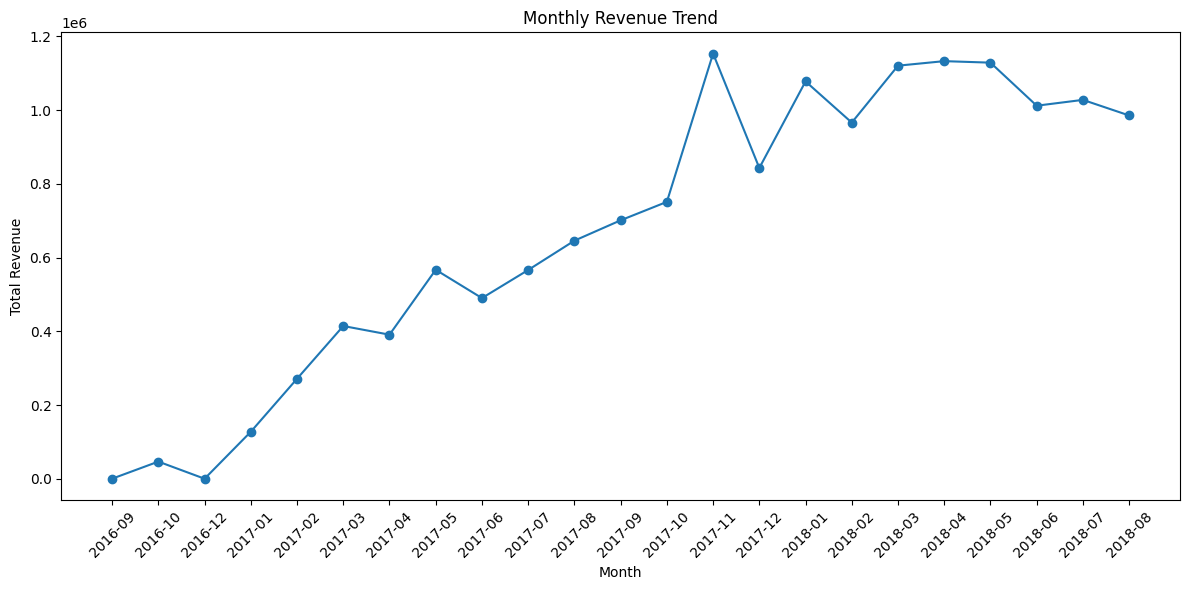

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales["order_month"], monthly_sales["total_revenue"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

### Key Insights: Monthly Revenue Trend

*   *Overall Growth:* Revenue shows a strong upward trajectory from September 2016 to August 2018.
*   *Major Peak:* A significant revenue surge occurred in late 2017 (November–December), nearly reaching $1.2M (\(1.2 \times 10^6\)).

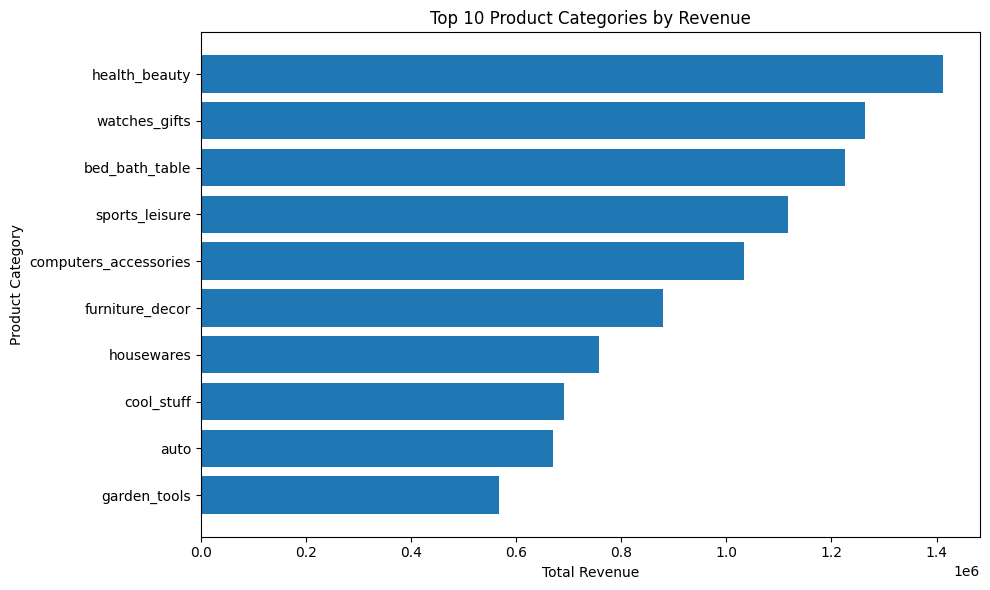

In [102]:
plt.figure(figsize=(10, 6))
plt.barh(top_categories["product_category"], top_categories["total_revenue"])
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Key Insights: Top 10 Product Categories by Revenue

*   *Top Performer:* health_beauty generates the highest total revenue, leading all categories and approaching the $1.4M 

*   *Strong Runners-Up:* watch gifts, bed bath table, and sports leisure form a tight second tier, each pulling in over $1.0M in revenue.

*   *Lowest in Top 10:* garden_tools ranks tenth, contributing the least revenue among the group at roughly $0.5M.

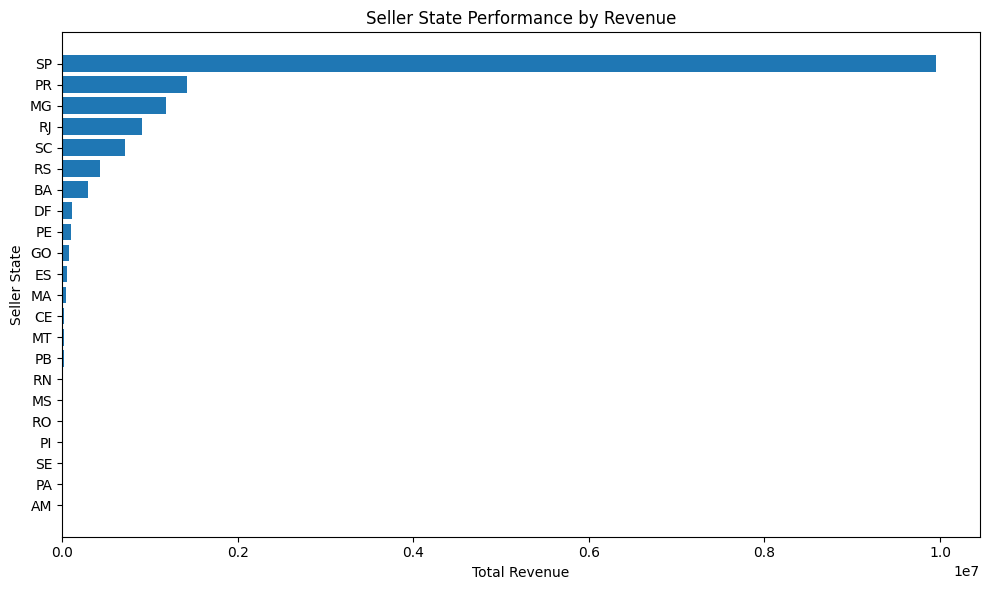

In [103]:
plt.figure(figsize=(10, 6))
plt.barh(seller_state_performance["seller_state"], seller_state_performance["total_revenue"])
plt.title("Seller State Performance by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Seller State")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Key Insights: Seller State Performance by Revenue

*   *Dominant Leader:* SP (São Paulo) vastly outperforms all other states, generating an overwhelming majority of the total revenue at over $8.0M .

*   *Secondary Market Tier:* PR (Paraná), MG (Minas Gerais), and RJ (Rio de Janeiro) form a secondary, much smaller cluster of contributors.

*   *Long Tail Distribution:* The remaining states represent a very steep drop-off, each contributing negligible revenue compared to the dominant leading response

### Section Summary

This section analyzed sales, product, and seller performance using advanced SQL techniques.

The analysis helped identify:

- Monthly revenue and order trends
- Month-over-month revenue growth
- Top revenue-generating product categories
- Product category revenue contribution
- Top-performing sellers
- Seller revenue contribution
- Seller performance by state
- Low-performing product categories

Advanced SQL techniques used in this section include:

- Joins
- Views
- Common Table Expressions
- Window functions
- `LAG()`
- `RANK()`
- `SUM() OVER()`
- Aggregations
- Revenue contribution analysis

This section provides a strong understanding of the major revenue drivers of the Olist marketplace.

## 5. Customer, Delivery & Satisfaction Analysis

This section analyzes customer behavior, delivery performance, and customer satisfaction.

The main objective is to understand:

- Which customer locations generate the highest business value
- Whether customers are mostly one-time buyers or repeat buyers
- Which customers are high-value, loyal, normal, or at-risk
- How well orders are delivered on time
- Which states face delivery delays
- Whether late delivery affects customer review scores

This section uses advanced SQL techniques such as CTEs, window functions, `NTILE()`, `CASE WHEN`, date functions, customer-level aggregation, and conditional aggregation.

In [104]:
conn.execute("DROP VIEW IF EXISTS customer_delivery_base;")

conn.execute("""
CREATE VIEW customer_delivery_base AS
SELECT
    o.order_id,
    o.customer_id,
    c.customer_unique_id,
    c.customer_city,
    c.customer_state,
    o.order_status,
    o.order_purchase_timestamp,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,
    strftime('%Y-%m', o.order_purchase_timestamp) AS order_month,
    oi.price,
    oi.freight_value,
    ROUND(oi.price + oi.freight_value, 2) AS total_order_item_value,
    r.review_score,
    CASE
        WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date 
        THEN 'Late'
        ELSE 'On Time'
    END AS delivery_status,
    ROUND(
        julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp),
        2
    ) AS delivery_days,
    ROUND(
        julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date),
        2
    ) AS delay_days
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
JOIN order_items oi
    ON o.order_id = oi.order_id
LEFT JOIN reviews r
    ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL;
""")

conn.commit()

print("customer_delivery_base view created successfully")

customer_delivery_base view created successfully


In [105]:
run_query("""
SELECT *
FROM customer_delivery_base
LIMIT 10;
""")

,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,order_month,price,freight_value,total_order_item_value,review_score,delivery_status,delivery_days,delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10,29.99,8.72,38.71,4,On Time,8.44,-7.11
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07,118.70,22.76,141.46,4,On Time,13.78,-5.36
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08,159.90,19.22,179.12,5,On Time,9.39,-17.25
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11,45.00,27.20,72.20,5,On Time,13.21,-12.98
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02,19.90,8.72,28.62,5,On Time,2.87,-9.24
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,80bb27c7c16e8f973207a5086ab329e2,congonhinhas,PR,delivered,2017-07-09 21:57:05,2017-07-26 10:57:55,2017-08-01 00:00:00,2017-07,147.90,27.36,175.26,4,On Time,16.54,-5.54
6,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,932afa1e708222e5821dac9cd5db4cae,nilopolis,RJ,delivered,2017-05-16 13:10:30,2017-05-26 12:55:51,2017-06-07 00:00:00,2017-05,59.99,15.17,75.16,5,On Time,9.99,-11.46
7,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,39382392765b6dc74812866ee5ee92a7,faxinalzinho,RS,delivered,2017-01-23 18:29:09,2017-02-02 14:08:10,2017-03-06 00:00:00,2017-01,19.90,16.05,35.95,1,On Time,9.82,-31.41
8,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,299905e3934e9e181bfb2e164dd4b4f8,sorocaba,SP,delivered,2017-07-29 11:55:02,2017-08-16 17:14:30,2017-08-23 00:00:00,2017-07,149.99,19.77,169.76,5,On Time,18.22,-6.28
9,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,f2a85dec752b8517b5e58a06ff3cd937,rio de janeiro,RJ,delivered,2017-05-16 19:41:10,2017-05-29 11:18:31,2017-06-07 00:00:00,2017-05,99.00,30.53,129.53,1,On Time,12.65,-8.53


In [106]:
#Customer Geography Analysis
customer_state_analysis = run_query("""
SELECT
    customer_state,
    COUNT(DISTINCT customer_unique_id) AS total_customers,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(SUM(total_order_item_value), 2) AS total_revenue,
    ROUND(SUM(total_order_item_value) / COUNT(DISTINCT order_id), 2) AS average_order_value
FROM customer_delivery_base
GROUP BY customer_state
ORDER BY total_revenue DESC;
""")

customer_state_analysis

,customer_state,total_customers,total_orders,total_revenue,average_order_value
0,SP,39149,40494,5798099.03,143.18
1,RJ,11917,12350,2063593.64,167.09
2,MG,11001,11354,1826486.53,160.87
3,RS,5167,5344,865683.26,161.99
4,PR,4769,4923,785095.06,159.47
5,SC,3449,3546,597067.83,168.38
6,BA,3158,3256,593408.37,182.25
7,DF,2019,2080,348601.41,167.60
8,GO,1895,1957,337665.51,172.54
9,ES,1928,1995,318466.51,159.63


### Customer Geography Findings

Top customer state: SP

Total customers: 39,149

Total orders: 40,494

Total revenue: 5,798,099.03

Average order value: 143.18

This state is the most valuable customer market based on revenue.

In [108]:
#Repeat Customer Analysis
repeat_customer_analysis = run_query("""
WITH customer_orders AS (
    SELECT
        customer_unique_id,
        COUNT(DISTINCT order_id) AS total_orders,
        ROUND(SUM(total_order_item_value), 2) AS total_spent
    FROM customer_delivery_base
    GROUP BY customer_unique_id
)

SELECT
    CASE
        WHEN total_orders = 1 THEN 'One-Time Customer'
        ELSE 'Repeat Customer'
    END AS customer_type,
    COUNT(*) AS total_customers,
    ROUND(AVG(total_orders), 2) AS average_orders_per_customer,
    ROUND(SUM(total_spent), 2) AS total_revenue,
    ROUND(AVG(total_spent), 2) AS average_customer_value
FROM customer_orders
GROUP BY customer_type;
""")

repeat_customer_analysis

,customer_type,total_customers,average_orders_per_customer,total_revenue,average_customer_value
0,One-Time Customer,90549,1.00,14564258.64,160.84
1,Repeat Customer,2801,2.11,924027.99,329.89


### Repeat Customer Finding

One-time customers: 90,549

Repeat customers: 2,801

Repeat customer rate: 3.00%

This shows whether the marketplace depends mainly on new customers or has strong customer retention.

In [110]:
#RFM Customer Segmentation
rfm_segments = run_query("""
WITH customer_rfm AS (
    SELECT
        customer_unique_id,
        MAX(order_purchase_timestamp) AS last_purchase_date,
        COUNT(DISTINCT order_id) AS frequency,
        ROUND(SUM(total_order_item_value), 2) AS monetary,
        ROUND(
            julianday((SELECT MAX(order_purchase_timestamp) FROM customer_delivery_base)) 
            - julianday(MAX(order_purchase_timestamp)),
            2
        ) AS recency_days
    FROM customer_delivery_base
    GROUP BY customer_unique_id
),

rfm_scores AS (
    SELECT
        customer_unique_id,
        last_purchase_date,
        recency_days,
        frequency,
        monetary,
        NTILE(4) OVER (ORDER BY recency_days DESC) AS recency_score,
        NTILE(4) OVER (ORDER BY frequency ASC) AS frequency_score,
        NTILE(4) OVER (ORDER BY monetary ASC) AS monetary_score
    FROM customer_rfm
)

SELECT
    customer_unique_id,
    last_purchase_date,
    recency_days,
    frequency,
    monetary,
    recency_score,
    frequency_score,
    monetary_score,
    recency_score + frequency_score + monetary_score AS rfm_total_score,
    CASE
        WHEN recency_score = 4 AND frequency_score >= 3 AND monetary_score >= 3
            THEN 'Best Customers'
        WHEN recency_score >= 3 AND frequency_score >= 3
            THEN 'Loyal Customers'
        WHEN recency_score >= 3 AND monetary_score >= 3
            THEN 'Potential High Value Customers'
        WHEN recency_score <= 2 AND frequency_score <= 2 AND monetary_score <= 2
            THEN 'At-Risk Customers'
        ELSE 'Normal Customers'
    END AS customer_segment
FROM rfm_scores
ORDER BY rfm_total_score DESC;
""")

rfm_segments.head(10)

,customer_unique_id,last_purchase_date,recency_days,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_total_score,customer_segment
0,5733ed5885d0b0f2f3bcb9b6e830c7a7,2018-05-07 17:08:23,113.91,1,273.36,4,4,4,12,Best Customers
1,f734901a12fa542a4bfea19410031ec1,2018-05-07 17:20:46,113.90,1,253.88,4,4,4,12,Best Customers
2,5d15c22ab8b1efd3c7ec3253f3531299,2018-05-07 17:25:59,113.90,1,398.46,4,4,4,12,Best Customers
3,88da21ad308ca9bff370909f980da689,2018-05-07 17:34:11,113.89,1,217.04,4,4,4,12,Best Customers
4,7bbcad674e8c0ed95d070049efee7646,2018-05-07 17:35:43,113.89,1,963.36,4,4,4,12,Best Customers
5,d2f79db37031301a54d560415cadac21,2018-05-07 18:43:39,113.85,1,413.77,4,4,4,12,Best Customers
6,e8f730c94f50e6b91bb5c5b2f923ea3e,2018-05-07 18:57:24,113.84,1,192.61,4,4,4,12,Best Customers
7,d242c2a33b19c5fab2ccf4f67dcaba86,2018-05-07 18:56:36,113.84,1,397.70,4,4,4,12,Best Customers
8,801b53359d2880a9bff63574103fb74c,2018-05-07 18:58:49,113.83,2,227.44,4,4,4,12,Best Customers
9,c01ac50f437f46cc8fffb6d1a01d8631,2018-05-07 19:12:47,113.82,1,305.90,4,4,4,12,Best Customers


In [111]:
rfm_summary = rfm_segments.groupby("customer_segment").agg(
    total_customers=("customer_unique_id", "count"),
    average_frequency=("frequency", "mean"),
    average_monetary=("monetary", "mean")
).reset_index()

rfm_summary["average_frequency"] = rfm_summary["average_frequency"].round(2)
rfm_summary["average_monetary"] = rfm_summary["average_monetary"].round(2)

rfm_summary

,customer_segment,total_customers,average_frequency,average_monetary
0,At-Risk Customers,23688,1.00,63.89
1,Best Customers,11892,1.07,273.33
2,Loyal Customers,11932,1.08,260.62
3,Normal Customers,45674,1.03,166.33
4,Potential High Value Customers,164,1.00,108.25


In [112]:
top_segment = rfm_summary.sort_values("total_customers", ascending=False).iloc[0]

print("RFM Customer Segmentation Finding")
print("---------------------------------")
print(f"Largest customer segment: {top_segment['customer_segment']}")
print(f"Total customers in this segment: {top_segment['total_customers']:,}")
print(f"Average purchase frequency: {top_segment['average_frequency']}")
print(f"Average monetary value: {top_segment['average_monetary']:,.2f}")
print("RFM segmentation helps identify high-value customers, loyal customers, and at-risk customers for targeted marketing.")

RFM Customer Segmentation Finding
---------------------------------
Largest customer segment: Normal Customers
Total customers in this segment: 45,674
Average purchase frequency: 1.03
Average monetary value: 166.33
RFM segmentation helps identify high-value customers, loyal customers, and at-risk customers for targeted marketing.


In [113]:
#Delivery Performance Overview
delivery_performance = run_query("""
SELECT
    delivery_status,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(COUNT(DISTINCT order_id) * 100.0 / 
        (SELECT COUNT(DISTINCT order_id) FROM customer_delivery_base), 2
    ) AS order_percentage,
    ROUND(AVG(delivery_days), 2) AS average_delivery_days,
    ROUND(AVG(delay_days), 2) AS average_delay_days
FROM customer_delivery_base
GROUP BY delivery_status
ORDER BY total_orders DESC;
""")

delivery_performance

,delivery_status,total_orders,order_percentage,average_delivery_days,average_delay_days
0,On Time,88644,91.89,10.86,-13.12
1,Late,7826,8.11,31.36,9.43


### Delivery Performance Findings

Late delivered orders: 7,826

Late delivery percentage: 8.11%

Late delivery is an important operational issue because it can directly affect customer satisfaction and review scores.

In [116]:
# Delivery Delay by Customer State
state_delivery_delay = run_query("""
SELECT
    customer_state,
    COUNT(DISTINCT order_id) AS total_orders,
    SUM(CASE WHEN delivery_status = 'Late' THEN 1 ELSE 0 END) AS late_orders,
    ROUND(
        SUM(CASE WHEN delivery_status = 'Late' THEN 1 ELSE 0 END) * 100.0 
        / COUNT(DISTINCT order_id),
        2
    ) AS late_delivery_percentage,
    ROUND(AVG(delivery_days), 2) AS average_delivery_days,
    ROUND(AVG(delay_days), 2) AS average_delay_days
FROM customer_delivery_base
GROUP BY customer_state
HAVING total_orders >= 100
ORDER BY late_delivery_percentage DESC;
""")

state_delivery_delay

,customer_state,total_orders,late_orders,late_delivery_percentage,average_delivery_days,average_delay_days
0,AL,397,104,26.20,24.48,-8.06
1,MA,717,163,22.73,21.58,-9.32
2,SE,335,61,18.21,21.47,-9.33
3,CE,1279,219,17.12,20.98,-10.44
4,PI,476,81,17.02,19.38,-10.84
5,BA,3256,508,15.60,19.26,-10.28
6,RJ,12350,1846,14.95,15.16,-11.29
7,TO,274,38,13.87,17.45,-11.65
8,PA,946,131,13.85,23.77,-13.55
9,ES,1995,273,13.68,15.66,-9.96


### State Delivery Delay Finding

State with highest late delivery percentage: AL

Total orders: 397

Late delivery percentage: 26.20%

Average delivery days: 24.48

This state needs logistics improvement because it has a high late delivery rate.

In [119]:
#Review Score Distribution
review_score_distribution = run_query("""
SELECT
    review_score,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(
        COUNT(DISTINCT order_id) * 100.0 / 
        (SELECT COUNT(DISTINCT order_id) FROM customer_delivery_base WHERE review_score IS NOT NULL),
        2
    ) AS review_percentage
FROM customer_delivery_base
WHERE review_score IS NOT NULL
GROUP BY review_score
ORDER BY review_score;
""")

review_score_distribution

,review_score,total_orders,review_percentage
0,1,9380,9.79
1,2,2938,3.07
2,3,7942,8.29
3,4,18943,19.77
4,5,56810,59.29


### Review Score Distribution Finding

Most common review score: 5

Orders with this review score: 56,810.0

Percentage share: 59.29%

This shows the most common customer satisfaction rating in the marketplace.

In [122]:
#Delivery Impact on Review Score
delivery_review_impact = run_query("""
SELECT
    delivery_status,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(AVG(review_score), 2) AS average_review_score,
    SUM(CASE WHEN review_score >= 4 THEN 1 ELSE 0 END) AS positive_reviews,
    SUM(CASE WHEN review_score <= 2 THEN 1 ELSE 0 END) AS negative_reviews,
    ROUND(
        SUM(CASE WHEN review_score >= 4 THEN 1 ELSE 0 END) * 100.0 / COUNT(review_score),
        2
    ) AS positive_review_percentage,
    ROUND(
        SUM(CASE WHEN review_score <= 2 THEN 1 ELSE 0 END) * 100.0 / COUNT(review_score),
        2
    ) AS negative_review_percentage
FROM customer_delivery_base
WHERE review_score IS NOT NULL
GROUP BY delivery_status;
""")

delivery_review_impact

,delivery_status,total_orders,average_review_score,positive_reviews,negative_reviews,positive_review_percentage,negative_review_percentage
0,Late,7661,2.55,2932,4677,34.25,54.64
1,On Time,88163,4.21,81557,11597,80.40,11.43


### Delivery Impact on Review Score Findings

Average review score for on-time deliveries: 4.21

Average review score for late deliveries: 2.55

Review score difference: 1.66

This indicates whether delivery delays are negatively affecting customer satisfaction.

In [124]:
delay_category_review = run_query("""
WITH delay_category AS (
    SELECT
        order_id,
        review_score,
        CASE
            WHEN delay_days <= 0 THEN 'On Time or Early'
            WHEN delay_days BETWEEN 1 AND 3 THEN '1-3 Days Late'
            WHEN delay_days BETWEEN 4 AND 7 THEN '4-7 Days Late'
            ELSE 'More Than 7 Days Late'
        END AS delay_category
    FROM customer_delivery_base
    WHERE review_score IS NOT NULL
)

SELECT
    delay_category,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(AVG(review_score), 2) AS average_review_score
FROM delay_category
GROUP BY delay_category
ORDER BY average_review_score DESC;
""")

delay_category_review

,delay_category,total_orders,average_review_score
0,On Time or Early,88169,4.21
1,1-3 Days Late,1363,3.47
2,More Than 7 Days Late,5008,2.39
3,4-7 Days Late,1284,2.17


### Delay Category Review Finding

Best review group: On Time or Early with average score 4.21

Worst review group: 4-7 Days Late with average score 2.17

This helps measure how delivery delay severity impacts customer satisfaction.

In [126]:
#Payment Behavior Analysis
payment_behavior = run_query("""
SELECT
    payment_type,
    COUNT(*) AS total_payment_records,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(SUM(payment_value), 2) AS total_payment_value,
    ROUND(AVG(payment_value), 2) AS average_payment_value,
    ROUND(AVG(payment_installments), 2) AS average_installments
FROM payments
GROUP BY payment_type
ORDER BY total_payment_value DESC;
""")

payment_behavior

,payment_type,total_payment_records,total_orders,total_payment_value,average_payment_value,average_installments
0,credit_card,76795,76505,12542084.19,163.32,3.51
1,boleto,19784,19784,2869361.27,145.03,1.00
2,voucher,5775,3866,379436.87,65.70,1.00
3,debit_card,1529,1528,217989.79,142.57,1.00
4,not_defined,3,3,0.00,0.00,1.00


### Payment Behavior Finding

Most valuable payment method: credit_card

Total payment value: 12,542,084.19

Total orders: 76,505

Average payment value: 163.32

This payment method contributes the highest transaction value in the marketplace.

### Section Summary

This section analyzed customer behavior, delivery performance, review scores, and payment behavior using advanced SQL.

The analysis helped identify:

- Top customer states by revenue
- One-time and repeat customer behavior
- Customer segments using RFM analysis
- Overall late delivery percentage
- States with high delivery delays
- Review score distribution
- Impact of delivery delay on review score
- Payment method preferences

Advanced SQL techniques used in this section include:

- CTEs
- Window functions
- `NTILE()`
- `CASE WHEN`
- Date functions using `julianday()`
- Conditional aggregation
- Customer segmentation
- Delivery delay classification

This section connects customer behavior with operational performance and customer satisfaction, making it one of the most important parts of the business analysis.

## 6. Key Insights & Business Recommendations

This final section summarizes the major findings from the SQL analysis and provides business recommendations based on marketplace performance, sales trends, product categories, sellers, customers, delivery operations, review scores, and payment behavior.

---

### 6.1 Key Business Insights

#### 1. Strong overall marketplace performance

The Olist marketplace recorded **99,441 total orders**, out of which **96,478 orders were successfully delivered**. This shows a strong delivery completion rate of around **97.02%**, indicating that most orders were successfully processed and fulfilled.

The marketplace served **96,096 unique customers** and worked with **3,095 sellers**, showing that Olist operated as a large multi-seller e-commerce platform with a wide customer and seller base.

Total revenue from delivered orders was **15,419,773.75**, with an **average order value of 159.83**.

---

#### 2. Revenue is driven by selected product categories

The highest revenue-generating category was **health_beauty**, generating **1,412,089.53** in total revenue. Other strong categories included **watches_gifts**, **bed_bath_table**, **sports_leisure**, and **computers_accessories**.

The top three categories — **health_beauty, watches_gifts, and bed_bath_table** — contributed around **25.64%** of total marketplace revenue. This shows that revenue is meaningfully concentrated in a few high-performing categories.

---

#### 3. Seller performance is highly concentrated in São Paulo

The seller state **SP** generated the highest revenue with **9,957,056.91**, supported by **1,769 sellers** and **68,641 orders**. This shows that São Paulo is the strongest seller hub for the marketplace.

The top seller generated **247,007.06** in revenue from **1,124 orders**, while the top 5 sellers together contributed around **7.44%** of total marketplace revenue.

This indicates that although the marketplace has thousands of sellers, a small group of sellers contributes significantly to business performance.

---

#### 4. Customer demand is also strongest in São Paulo

The customer state **SP** generated the highest revenue with **5,798,099.03**, coming from **39,149 customers** and **40,494 orders**.

Other important customer markets included **RJ, MG, RS, PR, SC, and BA**. This shows that customer demand is concentrated in major states, especially São Paulo, Rio de Janeiro, and Minas Gerais.

---

#### 5. Repeat customer rate is low

The analysis shows **90,549 one-time customers** and only **2,801 repeat customers**. This means the marketplace is highly dependent on new customers rather than repeat purchases.

Repeat customers had a much higher average customer value of **329.89**, compared to **160.84** for one-time customers. This indicates that repeat customers are more valuable and should be targeted with loyalty and retention strategies.

---

#### 6. RFM segmentation reveals customer value groups

The largest customer segment was **Normal Customers**, with **45,674 customers**. The analysis also identified:

* **23,688 At-Risk Customers**
* **11,892 Best Customers**
* **11,932 Loyal Customers**
* **164 Potential High Value Customers**

Best Customers had an average monetary value of **273.33**, while Loyal Customers had an average monetary value of **260.62**. At-Risk Customers had a much lower average monetary value of **63.89**.

This shows that targeted customer segmentation can help improve retention, revenue, and marketing efficiency.

---

#### 7. Delivery performance is strong overall, but late delivery has serious impact

Around **91.89% of orders were delivered on time**, while **8.11% were delivered late**.

On-time orders had an average delivery time of **10.86 days**, while late orders took around **31.36 days** on average. This shows a major operational gap between on-time and delayed orders.

States such as **AL, MA, SE, CE, PI, BA, and RJ** showed higher late delivery percentages, indicating that these regions require logistics improvement.

---

#### 8. Late delivery strongly reduces customer satisfaction

The average review score for on-time deliveries was **4.21**, while late deliveries had an average review score of only **2.55**.

The impact becomes clearer when delay severity is analyzed:

* **On Time or Early:** Average review score **4.21**
* **1–3 Days Late:** Average review score **3.47**
* **4–7 Days Late:** Average review score **2.17**
* **More Than 7 Days Late:** Average review score **2.39**

This confirms that delivery delays have a strong negative impact on customer satisfaction.

---

#### 9. Customer satisfaction is generally positive

The overall average review score was **4.09 out of 5**. Around **59.29% of orders received a 5-star review**, while **19.77% received a 4-star review**.

This means most customers had a positive experience. However, the presence of low review scores, especially among delayed orders, shows that logistics issues can damage customer experience.

---

#### 10. Credit card is the dominant payment method

The most valuable payment method was **credit_card**, contributing **12,542,084.19** in total payment value across **76,505 orders**.

Other payment methods included **boleto, voucher, debit_card, and not_defined**. Credit card payments clearly dominate transaction value and order volume, showing strong customer preference for card-based payments.

---

### 6.2 Business Recommendations

#### 1. Improve logistics in high-delay states

States such as **AL, MA, SE, CE, PI, BA, and RJ** showed high late delivery percentages. Olist should work on improving logistics partnerships, route planning, delivery tracking, and seller dispatch speed in these regions.

Improving delivery performance can directly improve customer satisfaction and review scores.

---

#### 2. Focus marketing on high-performing categories

Categories such as **health_beauty, watches_gifts, bed_bath_table, sports_leisure, and computers_accessories** are major revenue drivers.

Olist should prioritize these categories for:

* Promotional campaigns
* Featured product listings
* Inventory planning
* Seller partnerships
* Seasonal discounts

This can help increase revenue from categories that already show strong customer demand.

---

#### 3. Build customer retention and loyalty campaigns

The repeat customer rate is low, but repeat customers have much higher average customer value.

Olist should introduce:

* Loyalty rewards
* Personalized offers
* Repeat purchase discounts
* Email or app-based reactivation campaigns
* Category-based recommendations

This can help convert one-time customers into repeat buyers.

---

#### 4. Use RFM segmentation for targeted marketing

RFM segmentation identified Best Customers, Loyal Customers, Normal Customers, and At-Risk Customers.

Recommended actions:

* Offer loyalty benefits to Best Customers
* Give personalized product recommendations to Loyal Customers
* Send discount campaigns to At-Risk Customers
* Use reactivation offers for inactive customers
* Increase engagement with Normal Customers

This will make marketing more targeted and cost-effective.

---

#### 5. Support and monitor high-performing sellers

Top sellers contribute significantly to revenue. Olist should maintain strong relationships with these sellers by giving them better visibility, seller support, and performance dashboards.

At the same time, Olist should also help mid-level sellers improve through training, better product listing quality, pricing guidance, and delivery support.

---

#### 6. Reduce delivery delays to improve review scores

The analysis clearly shows that late delivery reduces average review scores. Olist should focus on reducing delivery delays because customer satisfaction is strongly connected with delivery performance.

Operational improvements should include:

* Faster seller dispatch
* Better estimated delivery dates
* Real-time delivery monitoring
* Stronger logistics partnerships
* Region-wise delay tracking

---

#### 7. Strengthen São Paulo as a core business hub

Both seller performance and customer demand are strongest in **SP**. Olist should continue strengthening this region because it is the largest revenue contributor from both supply and demand sides.

At the same time, Olist can use the São Paulo model to improve marketplace performance in other high-potential states.

---

### 6.3 Final Conclusion

This project analyzed the Olist e-commerce marketplace using advanced SQL and an ETL-based workflow. The analysis covered business KPIs, revenue trends, product performance, seller performance, customer behavior, RFM segmentation, delivery efficiency, review scores, and payment behavior.

The key finding is that Olist has a strong marketplace foundation with high order volume, wide customer reach, active seller participation, and generally positive customer satisfaction. However, the business has improvement opportunities in customer retention, delivery performance, regional logistics, and seller development.

Advanced SQL techniques such as joins, CTEs, views, window functions, ranking, `LAG()`, `NTILE()`, `CASE WHEN`, date functions, and conditional aggregation were used to generate business insights.

Overall, this project demonstrates how SQL can be used not only for data extraction but also for solving real business problems and supporting data-driven decision-making.
